# Membangun Baseline Forecasting PM2.5 dengan LightGBM

Notebook ini digunakan untuk membangun **baseline model forecasting PM2.5 Jakarta** menggunakan algoritma **LightGBM Regressor**.

Input utama notebook ini adalah tiga dataset hasil preprocessing dan feature engineering:

```text
dataset_h6.csv
dataset_h12.csv
dataset_h24.csv
```

Ketiga dataset tersebut merepresentasikan horizon prediksi yang berbeda:

| Dataset | Horizon Prediksi | Target |
|---|---:|---|
| `dataset_h6.csv` | 6 jam ke depan | `target_pm25_t_plus_6` |
| `dataset_h12.csv` | 12 jam ke depan | `target_pm25_t_plus_12` |
| `dataset_h24.csv` | 24 jam ke depan | `target_pm25_t_plus_24` |

Tujuan utama notebook ini adalah memperoleh **baseline performance** untuk setiap horizon. Baseline ini penting karena akan menjadi titik pembanding awal sebelum dilakukan pengembangan model yang lebih kompleks, seperti hyperparameter tuning, model comparison, ablation study, atau ensemble.

Dengan kata lain, notebook ini menjawab pertanyaan utama:

> Seberapa baik performa awal model LightGBM sederhana untuk memprediksi PM2.5 pada horizon 6 jam, 12 jam, dan 24 jam ke depan?

## Strategi Validasi Berbasis Waktu

Notebook ini menggunakan pendekatan **time-based split**, bukan random split.

Pendekatan ini penting karena data PM2.5 merupakan data time series. Jika data dibagi secara acak, maka ada risiko informasi dari masa depan masuk ke proses training. Kondisi tersebut dapat menyebabkan hasil evaluasi terlihat terlalu bagus, tetapi tidak realistis ketika model digunakan untuk prediksi waktu mendatang.

Alur validasi dalam notebook ini adalah:

```text
Dataset horizon
        ↓
Urutkan berdasarkan datetime dan station_slug
        ↓
Ambil unique datetime
        ↓
Gunakan 80% waktu awal sebagai train
        ↓
Gunakan 20% waktu akhir sebagai validation
        ↓
Latih LightGBM pada train
        ↓
Evaluasi pada validation
```

Dengan strategi ini, data validation selalu berada setelah data training secara kronologis. Hal ini membuat evaluasi lebih mendekati skenario nyata, yaitu model dilatih menggunakan data historis dan diuji pada periode setelahnya.

Pembagian data dilakukan secara terpisah untuk setiap horizon karena masing-masing dataset memiliki jumlah baris dan target yang berbeda.

## Analisis Fitur, Korelasi, dan Interpretasi Awal

Selain melatih model baseline, notebook ini juga membuat analisis tambahan berupa:

1. Feature importance dari LightGBM.
2. Grafik MAE per horizon.
3. Correlation heatmap antara fitur numerik dan target.

Feature importance digunakan untuk melihat fitur mana yang paling sering digunakan oleh LightGBM dalam membangun pohon keputusan. Informasi ini berguna untuk memahami variabel mana yang paling berkontribusi terhadap prediksi PM2.5.

Correlation heatmap digunakan untuk melihat hubungan linear antara fitur numerik dan target PM2.5 masa depan. Korelasi tidak selalu berarti hubungan sebab-akibat, tetapi dapat membantu mengidentifikasi fitur yang memiliki hubungan kuat dengan target.

Secara umum, bagian analisis fitur ini membantu menjawab:

| Analisis | Tujuan |
|---|---|
| Feature importance | Melihat fitur yang paling dominan menurut model |
| Correlation heatmap | Melihat hubungan numerik antarfitur dan target |
| MAE by horizon | Membandingkan performa model pada horizon berbeda |

Dengan adanya analisis ini, notebook tidak hanya menghasilkan angka MAE dan RMSE, tetapi juga memberi gambaran awal tentang struktur informasi dalam dataset.

## Output Baseline dan Perannya dalam Eksperimen Lanjutan

Output utama notebook ini terdiri dari metrik evaluasi, file prediksi, model baseline, feature importance, dan visualisasi pendukung.

Secara umum, output notebook dapat digunakan untuk beberapa kebutuhan:

| Output | Fungsi |
|---|---|
| Metrik MAE dan RMSE | Mengukur performa baseline setiap horizon |
| File prediksi validation | Membandingkan nilai aktual dan prediksi |
| Model `.pkl` | Menyimpan model agar bisa digunakan ulang |
| Feature importance | Menganalisis fitur yang dianggap penting oleh LightGBM |
| Correlation heatmap | Melihat hubungan fitur numerik dengan target |
| Grafik MAE by horizon | Membandingkan kesulitan prediksi antarhorizon |

Notebook ini menjadi tahap **baseline experimentation** dalam pipeline forecasting PM2.5.

Hasil dari notebook ini dapat digunakan sebagai pembanding untuk tahap berikutnya, misalnya:

1. Tuning hyperparameter LightGBM.
2. Membandingkan LightGBM dengan XGBoost dan CatBoost.
3. Melakukan ablation study terhadap kelompok fitur.
4. Membandingkan performa antarhorizon.
5. Mengembangkan ensemble atau stacking model.

## Menyiapkan Library, Path Output, dan Fungsi Dasar Modeling

Cell ini menyiapkan seluruh komponen dasar yang dibutuhkan untuk menjalankan baseline modeling.

Library yang digunakan meliputi:

| Library | Fungsi |
|---|---|
| `pickle` | Menyimpan model LightGBM dalam format `.pkl` |
| `pathlib.Path` | Mengatur path folder output secara lebih rapi |
| `numpy` | Operasi numerik |
| `pandas` | Membaca dan mengolah dataset |
| `matplotlib.pyplot` | Membuat visualisasi |
| `sklearn.metrics` | Menghitung MAE dan RMSE |
| `LGBMRegressor` | Model baseline forecasting PM2.5 |

Cell ini juga membuat folder output:

```text
outputs_baseline/
```

Folder tersebut digunakan untuk menyimpan metrik, file prediksi, model, feature importance, dan grafik baseline.

### Dataset Input

Dataset input didefinisikan dalam dictionary `DATASET_PATHS`.

| Horizon | File |
|---:|---|
| 6 | `dataset_h6.csv` |
| 12 | `dataset_h12.csv` |
| 24 | `dataset_h24.csv` |

Dengan struktur dictionary seperti ini, proses training dapat dilakukan secara otomatis menggunakan loop untuk semua horizon.

### Fungsi `load_dataset()`

Fungsi ini bertugas membaca dataset, mengubah kolom `datetime` dan `date` menjadi format datetime, lalu mengurutkan data berdasarkan:

```text
datetime
station_slug
```

Pengurutan ini penting karena dataset bersifat time series. Model dan proses split harus mengikuti urutan waktu agar tidak terjadi pencampuran data masa depan ke data masa lalu.

### Fungsi `make_time_split()`

Fungsi ini membagi data menjadi train dan validation berdasarkan unique datetime.

Strateginya adalah:

| Bagian | Proporsi |
|---|---:|
| Train | 80% waktu awal |
| Validation | 20% waktu akhir |

Split dilakukan berdasarkan waktu, bukan random. Hal ini membuat evaluasi lebih realistis untuk forecasting.

### Fungsi `prepare_xy()`

Fungsi ini menyiapkan fitur `X` dan target `y` untuk LightGBM.

Beberapa kolom dikeluarkan dari fitur karena tidak digunakan langsung dalam training:

| Kolom | Alasan |
|---|---|
| Kolom target | Tidak boleh menjadi fitur karena merupakan label yang diprediksi |
| `datetime` | Kolom waktu mentah, bukan fitur numerik langsung |
| `date` | Kolom tanggal mentah |
| `station_name` | Redundan dengan `station_slug` |
| `lokasi` | Informasi teks lokasi |
| `season_simple` | Kolom string musim |
| `pm25_raw` | Backup nilai asli sebelum imputasi |
| `pm25_clean_full` | Duplikat dari PM2.5 final jika tersedia |

Kolom bertipe object yang masih tersisa akan diubah menjadi `category` agar dapat diproses oleh LightGBM.

In [7]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor

SEED = 42
OUT_DIR = Path("outputs_baseline")
OUT_DIR.mkdir(exist_ok=True)

DATASET_PATHS = {
    6: "dataset_h6.csv",
    12: "dataset_h12.csv",
    24: "dataset_h24.csv",
}

def load_dataset(path):
    df = pd.read_csv(path)
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.sort_values(["datetime", "station_slug"]).reset_index(drop=True)
    return df

def make_time_split(df, valid_ratio=0.2):
    """
    Split berdasarkan unique datetime supaya tidak random dan tidak leakage waktu.
    """
    unique_times = np.array(sorted(df["datetime"].dropna().unique()))
    split_idx = int(len(unique_times) * (1 - valid_ratio))
    split_idx = max(1, min(split_idx, len(unique_times) - 1))
    cutoff = unique_times[split_idx]

    train_df = df[df["datetime"] < cutoff].copy()
    valid_df = df[df["datetime"] >= cutoff].copy()

    return train_df, valid_df, cutoff

def prepare_xy(df, target_col):
    """
    Siapkan X, y untuk LightGBM.
    """
    exclude_cols = {
        target_col,
        "datetime",
        "date",
        "station_name",
        "lokasi",
        "season_simple",      # string, optional
        "pm25_raw",           # backup raw
        "pm25_clean_full",    # duplikat dengan pm25 final
    }
    exclude_cols = {c for c in exclude_cols if c in df.columns}

    feature_cols = [c for c in df.columns if c not in exclude_cols]
    X = df[feature_cols].copy()
    y = df[target_col].copy()

    # object -> category supaya LightGBM bisa handle
    for col in X.columns:
        if X[col].dtype == "object":
            X[col] = X[col].astype("category")

    return X, y, feature_cols

## Melatih LightGBM Baseline untuk Setiap Horizon

Cell ini menjalankan proses training baseline LightGBM untuk tiga horizon prediksi, yaitu 6 jam, 12 jam, dan 24 jam ke depan.

Proses dilakukan menggunakan loop berdasarkan `DATASET_PATHS`, sehingga setiap dataset horizon diproses dengan alur yang sama.

Tahapan dalam setiap horizon adalah:

1. Membaca dataset horizon.
2. Menentukan nama kolom target.
3. Membagi data menjadi train dan validation menggunakan time-based split.
4. Menyiapkan fitur dan target.
5. Melatih `LGBMRegressor`.
6. Membuat prediksi pada train dan validation.
7. Menghitung MAE dan RMSE.
8. Menyimpan metrik, prediksi validation, model, dan feature importance.

### Hasil Split Data

| Horizon | Cutoff Validation | Train Shape | Validation Shape |
|---:|---|---:|---:|
| H6 | `2025-08-05 00:00:00` | `(124680, 155)` | `(31170, 155)` |
| H12 | `2025-08-04 19:00:00` | `(124655, 156)` | `(31165, 156)` |
| H24 | `2025-08-04 09:00:00` | `(124605, 167)` | `(31155, 167)` |

Perbedaan cutoff terjadi karena masing-masing horizon memiliki jumlah baris yang sedikit berbeda setelah target masa depan dibuat.

### Hasil Evaluasi Baseline

| Horizon | Train MAE | Valid MAE | Train RMSE | Valid RMSE |
|---:|---:|---:|---:|---:|
| H6 | 2.6856 | 3.4700 | 4.5566 | 9.5971 |
| H12 | 4.3382 | 5.8252 | 6.6974 | 13.8320 |
| H24 | 6.3312 | 9.2275 | 8.9156 | 19.3796 |

Hasil ini menunjukkan bahwa semakin panjang horizon prediksi, performa model semakin menurun. Hal ini wajar karena memprediksi PM2.5 24 jam ke depan lebih sulit dibanding memprediksi 6 jam ke depan.

### Interpretasi Awal

| Pola | Makna |
|---|---|
| H6 memiliki error paling rendah | Prediksi jangka pendek lebih mudah karena informasi terbaru masih sangat relevan |
| H12 memiliki error menengah | Model mulai kehilangan sebagian informasi jangka pendek |
| H24 memiliki error paling tinggi | Prediksi satu hari ke depan jauh lebih sulit dan membutuhkan fitur temporal yang lebih kuat |
| Validation error lebih tinggi dari train error | Model bekerja lebih baik pada data training dibanding data masa depan |

Perbedaan train dan validation error masih wajar untuk baseline. Namun, gap yang cukup besar pada RMSE menunjukkan adanya sebagian error besar pada validation, kemungkinan karena lonjakan PM2.5 atau pola ekstrem yang sulit diprediksi.

### Output yang Disimpan

Untuk setiap horizon, cell ini menyimpan:

| Jenis Output | Format Nama File |
|---|---|
| Prediksi validation | `baseline_valid_predictions_h{horizon}.csv` |
| Model LightGBM | `lgbm_baseline_h{horizon}.pkl` |
| Feature importance | `feature_importance_h{horizon}.csv` |

Selain itu, metrik seluruh horizon disimpan dalam:

```text
outputs_baseline/baseline_metrics_by_horizon.csv
```

In [8]:
all_metrics = []
all_feature_importances = []

for horizon, path in DATASET_PATHS.items():
    print(f"\n===== TRAIN BASELINE H{horizon} =====")
    df_h = load_dataset(path)

    target_col = f"target_pm25_t_plus_{horizon}"
    if target_col not in df_h.columns:
        raise ValueError(f"Kolom target tidak ditemukan: {target_col}")

    train_df, valid_df, cutoff = make_time_split(df_h, valid_ratio=0.2)
    print("cutoff datetime:", cutoff)
    print("train shape:", train_df.shape)
    print("valid shape:", valid_df.shape)

    X_train, y_train, feature_cols = prepare_xy(train_df, target_col)
    X_valid, y_valid, _ = prepare_xy(valid_df, target_col)

    # LightGBM baseline - default-ish params
    model = LGBMRegressor(
        random_state=SEED,
        verbose=-1
    )

    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_valid = model.predict(X_valid)

    train_mae = mean_absolute_error(y_train, pred_train)
    valid_mae = mean_absolute_error(y_valid, pred_valid)

    train_rmse = np.sqrt(mean_squared_error(y_train, pred_train))
    valid_rmse = np.sqrt(mean_squared_error(y_valid, pred_valid))

    metrics_row = {
        "horizon": horizon,
        "target_col": target_col,
        "n_train": len(train_df),
        "n_valid": len(valid_df),
        "cutoff_datetime": cutoff,
        "train_mae": train_mae,
        "valid_mae": valid_mae,
        "train_rmse": train_rmse,
        "valid_rmse": valid_rmse,
    }
    all_metrics.append(metrics_row)

    print("Train MAE :", round(train_mae, 4))
    print("Valid MAE :", round(valid_mae, 4))
    print("Train RMSE:", round(train_rmse, 4))
    print("Valid RMSE:", round(valid_rmse, 4))

    # simpan prediksi valid
    pred_valid_df = valid_df[["datetime", "station_slug", target_col]].copy()
    pred_valid_df["prediction"] = pred_valid
    pred_valid_df.to_csv(OUT_DIR / f"baseline_valid_predictions_h{horizon}.csv", index=False)

    # simpan model
    with open(OUT_DIR / f"lgbm_baseline_h{horizon}.pkl", "wb") as f:
        pickle.dump(model, f)

    # feature importance
    fi = pd.DataFrame({
        "feature": feature_cols,
        "importance": model.feature_importances_,
        "horizon": horizon,
    }).sort_values("importance", ascending=False)

    fi.to_csv(OUT_DIR / f"feature_importance_h{horizon}.csv", index=False)
    all_feature_importances.append(fi)

metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv(OUT_DIR / "baseline_metrics_by_horizon.csv", index=False)

print("\n=== BASELINE MAE FOR EACH HORIZON ===")
print(metrics_df[["horizon", "train_mae", "valid_mae", "train_rmse", "valid_rmse"]])

metrics_df


===== TRAIN BASELINE H6 =====
cutoff datetime: 2025-08-05 00:00:00
train shape: (124680, 155)
valid shape: (31170, 155)
Train MAE : 2.6856
Valid MAE : 3.47
Train RMSE: 4.5566
Valid RMSE: 9.5971

===== TRAIN BASELINE H12 =====
cutoff datetime: 2025-08-04 19:00:00
train shape: (124655, 156)
valid shape: (31165, 156)
Train MAE : 4.3382
Valid MAE : 5.8252
Train RMSE: 6.6974
Valid RMSE: 13.832

===== TRAIN BASELINE H24 =====
cutoff datetime: 2025-08-04 09:00:00
train shape: (124605, 167)
valid shape: (31155, 167)
Train MAE : 6.3312
Valid MAE : 9.2275
Train RMSE: 8.9156
Valid RMSE: 19.3796

=== BASELINE MAE FOR EACH HORIZON ===
   horizon  train_mae  valid_mae  train_rmse  valid_rmse
0        6   2.685629   3.469969    4.556632    9.597092
1       12   4.338178   5.825226    6.697414   13.832026
2       24   6.331181   9.227488    8.915595   19.379571


,horizon,target_col,n_train,n_valid,cutoff_datetime,train_mae,valid_mae,train_rmse,valid_rmse
0,6,target_pm25_t_plus_6,124680,31170,2025-08-05 00:00:00,2.685629,3.469969,4.556632,9.597092
1,12,target_pm25_t_plus_12,124655,31165,2025-08-04 19:00:00,4.338178,5.825226,6.697414,13.832026
2,24,target_pm25_t_plus_24,124605,31155,2025-08-04 09:00:00,6.331181,9.227488,8.915595,19.379571


## Membandingkan MAE Baseline antarHorizon

Cell ini membaca file:

```text
outputs_baseline/baseline_metrics_by_horizon.csv
```

Kemudian membuat grafik perbandingan MAE untuk train dan validation pada setiap horizon.

Grafik yang dibuat menampilkan:

| Garis | Makna |
|---|---|
| Train MAE | Error model pada data training |
| Valid MAE | Error model pada data validation |

Output grafik disimpan sebagai:

```text
outputs_baseline/baseline_mae_by_horizon.png
```

### Interpretasi Grafik

Dari hasil metrik sebelumnya, nilai MAE meningkat dari H6 ke H24.

| Horizon | Valid MAE |
|---:|---:|
| H6 | 3.4700 |
| H12 | 5.8252 |
| H24 | 9.2275 |

Pola ini menunjukkan bahwa prediksi menjadi semakin sulit ketika horizon semakin panjang.

Secara konseptual, hal ini masuk akal karena:

1. Prediksi 6 jam ke depan masih sangat dipengaruhi oleh kondisi PM2.5 terbaru.
2. Prediksi 12 jam ke depan mulai membutuhkan pola setengah harian.
3. Prediksi 24 jam ke depan membutuhkan pemahaman pola harian, musiman, cuaca, dan dinamika polutan yang lebih kompleks.

Grafik ini penting sebagai ringkasan visual baseline. Jika model hasil tuning atau model lain tidak mampu mengalahkan baseline ini, maka model tersebut belum memberikan peningkatan yang berarti.

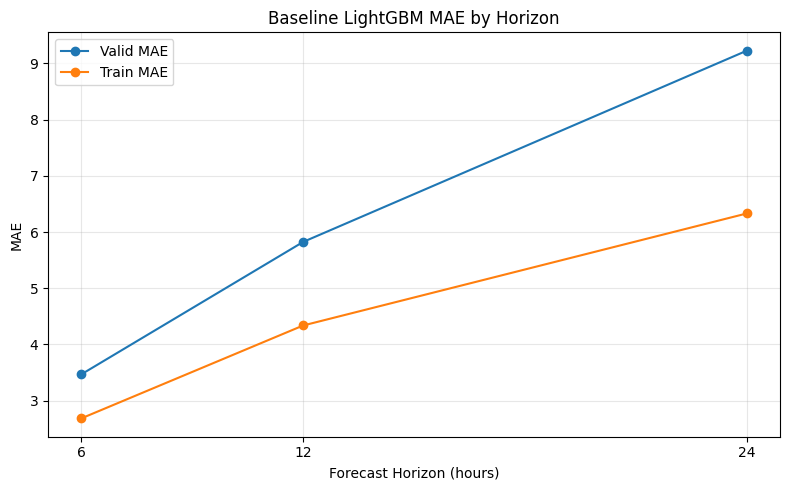

In [9]:
metrics_df = pd.read_csv(OUT_DIR / "baseline_metrics_by_horizon.csv")

plt.figure(figsize=(8, 5))
plt.plot(metrics_df["horizon"], metrics_df["valid_mae"], marker="o", label="Valid MAE")
plt.plot(metrics_df["horizon"], metrics_df["train_mae"], marker="o", label="Train MAE")
plt.xticks(metrics_df["horizon"])
plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("MAE")
plt.title("Baseline LightGBM MAE by Horizon")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "baseline_mae_by_horizon.png", dpi=200, bbox_inches="tight")
plt.show()

## Membaca Hubungan Fitur dan Target melalui Correlation Heatmap

Cell ini membuat correlation heatmap untuk masing-masing horizon prediksi.

Fungsi `plot_corr_heatmap()` bekerja dengan langkah berikut:

1. Mengambil hanya kolom numerik dari dataset.
2. Menghitung matriks korelasi antarvariabel.
3. Mengambil `top_n` fitur numerik yang memiliki korelasi absolut tertinggi dengan target.
4. Membuat heatmap dari fitur terpilih dan target.
5. Menyimpan hasil heatmap ke file gambar.

Jumlah fitur teratas yang digunakan adalah:

```text
top_n = 12
```

Artinya, setiap heatmap menampilkan 12 fitur numerik yang paling berkorelasi dengan target, ditambah kolom target itu sendiri.

### Output yang Dihasilkan

Cell ini menghasilkan tiga file heatmap:

| Horizon | File Output |
|---:|---|
| H6 | `outputs_baseline/eda_05_correlation_h6.png` |
| H12 | `outputs_baseline/eda_05_correlation_h12.png` |
| H24 | `outputs_baseline/eda_05_correlation_h24.png` |

### Fungsi Analisis Korelasi

Correlation heatmap berguna untuk melihat hubungan awal antara fitur dan target.

Namun, interpretasinya perlu hati-hati karena:

| Catatan | Penjelasan |
|---|---|
| Korelasi hanya menangkap hubungan linear | Hubungan non-linear bisa saja tidak terlihat kuat |
| Korelasi bukan sebab-akibat | Fitur yang berkorelasi tinggi belum tentu menyebabkan perubahan target |
| Fitur time series sering saling berkorelasi | Lag dan rolling PM2.5 bisa memiliki hubungan kuat satu sama lain |
| LightGBM dapat menangkap interaksi non-linear | Feature importance model bisa berbeda dari hasil korelasi |

Dengan demikian, heatmap ini sebaiknya digunakan sebagai alat eksplorasi awal, bukan sebagai satu-satunya dasar seleksi fitur.

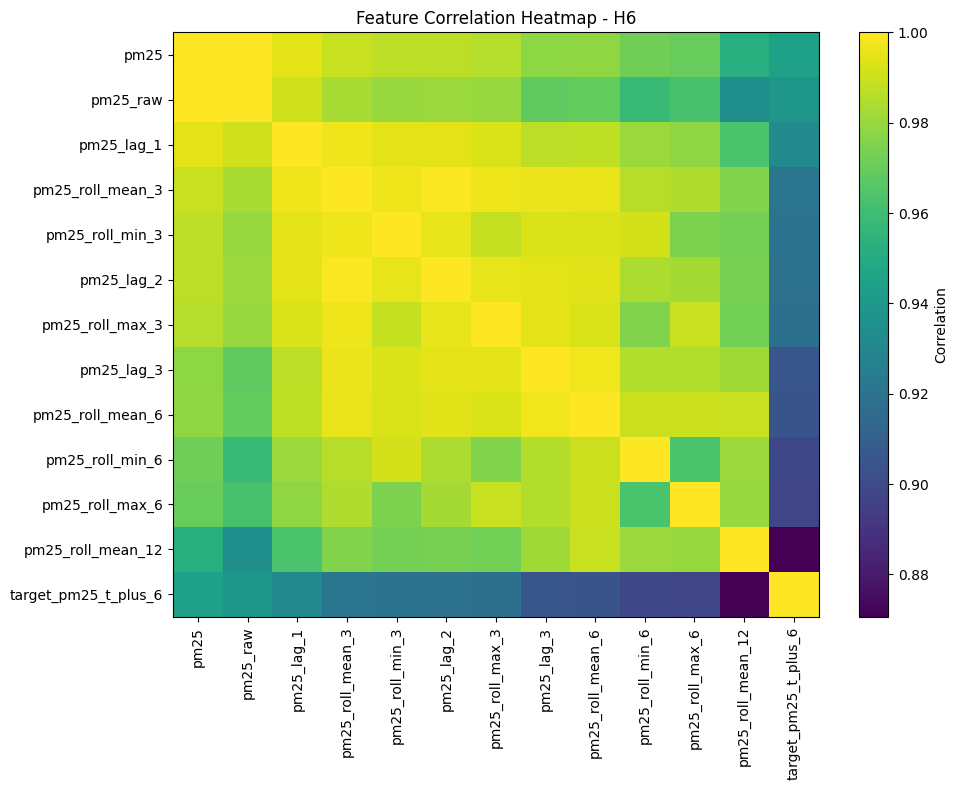

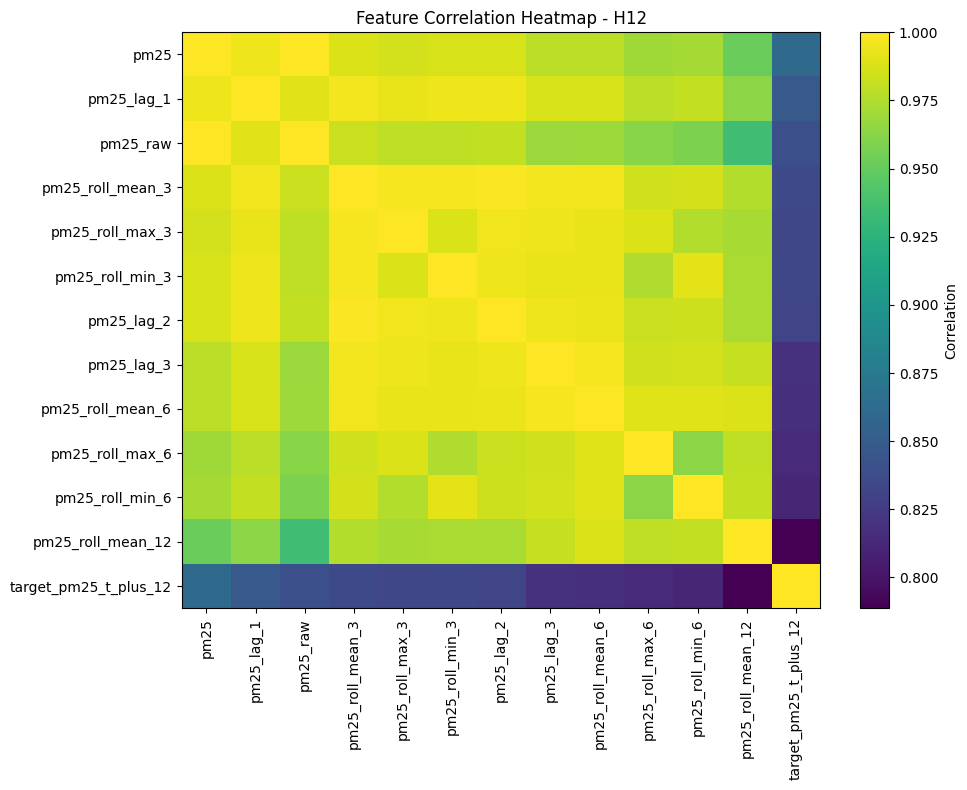

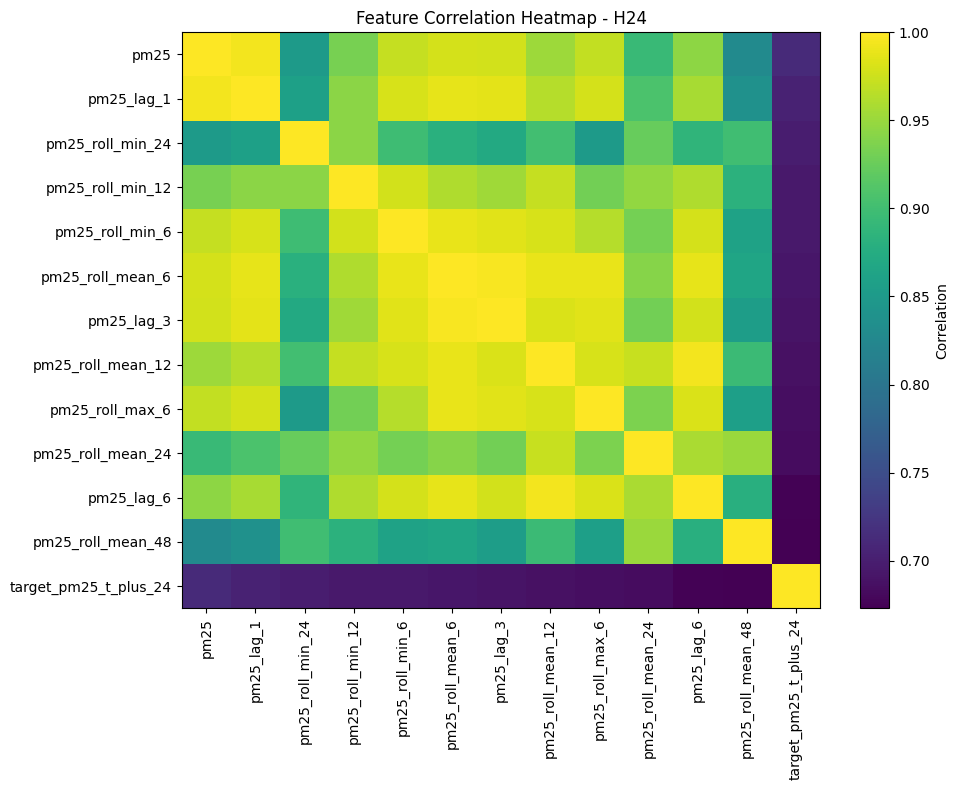

In [10]:
def plot_corr_heatmap(df, target_col, horizon, top_n=12, save_path=None):
    """
    Ambil top-N fitur numerik yang paling berkorelasi dengan target,
    lalu plot heatmap korelasinya.
    """
    numeric_df = df.select_dtypes(include=[np.number]).copy()

    if target_col not in numeric_df.columns:
        raise ValueError(f"{target_col} tidak ditemukan di kolom numerik.")

    corr = numeric_df.corr()

    # ambil fitur paling relevan ke target
    top_features = (
        corr[target_col]
        .drop(target_col)
        .abs()
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )

    selected = top_features + [target_col]
    corr_sub = corr.loc[selected, selected]

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr_sub.values, aspect="auto")

    ax.set_xticks(range(len(selected)))
    ax.set_yticks(range(len(selected)))
    ax.set_xticklabels(selected, rotation=90)
    ax.set_yticklabels(selected)
    ax.set_title(f"Feature Correlation Heatmap - H{horizon}")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Correlation")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

    return corr_sub

# heatmap per horizon
corr_results = {}

for horizon, path in DATASET_PATHS.items():
    df_h = load_dataset(path)
    target_col = f"target_pm25_t_plus_{horizon}"

    corr_sub = plot_corr_heatmap(
        df=df_h,
        target_col=target_col,
        horizon=horizon,
        top_n=12,
        save_path=OUT_DIR / f"eda_05_correlation_h{horizon}.png"
    )
    corr_results[horizon] = corr_sub

/tmp/ipykernel_1226/1412721229.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


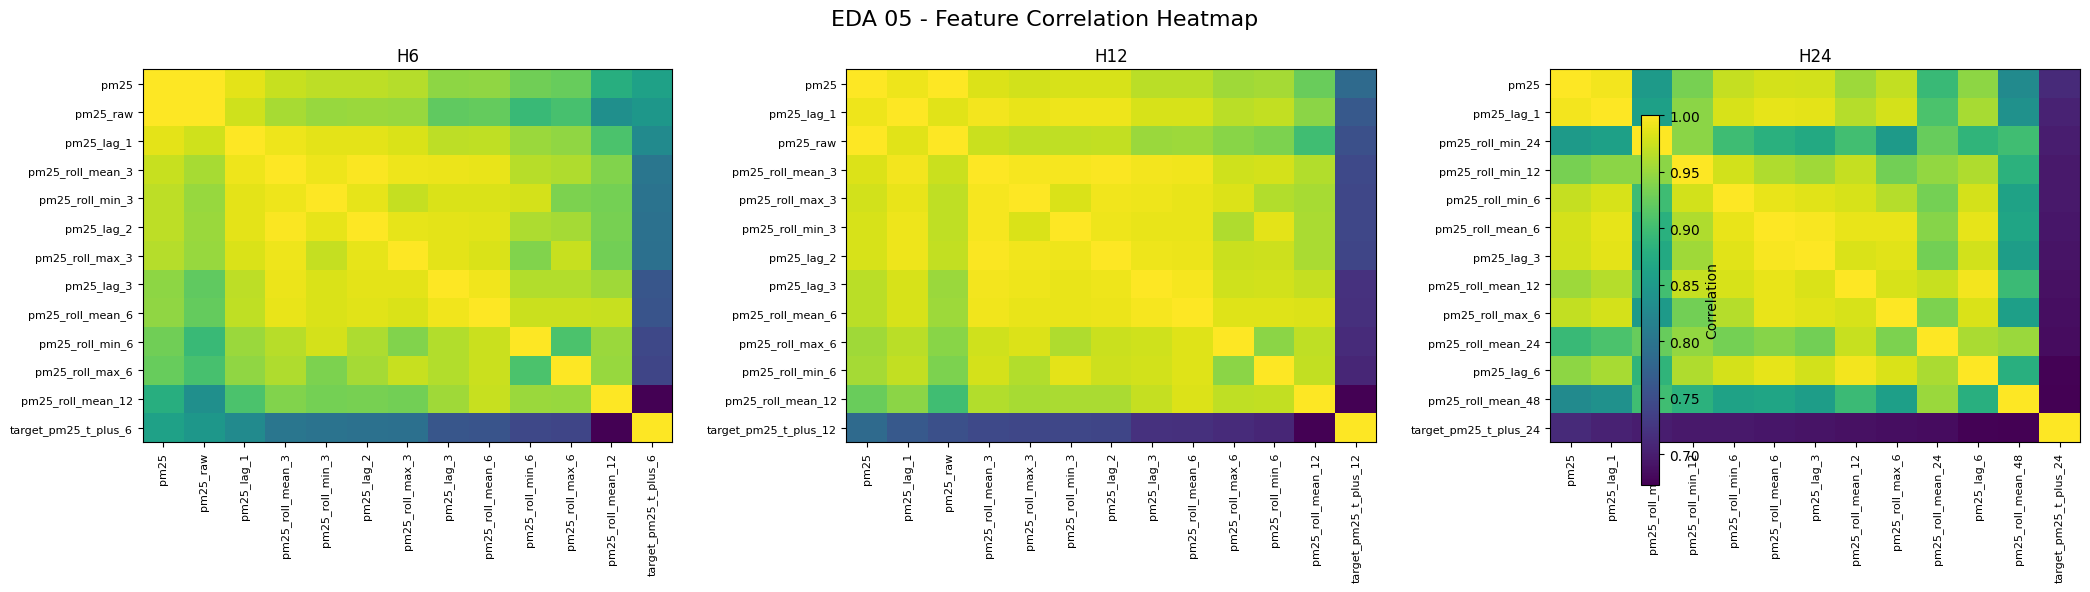

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, horizon in zip(axes, [6, 12, 24]):
    corr_sub = corr_results[horizon]
    labels = corr_sub.columns.tolist()

    im = ax.imshow(corr_sub.values, aspect="auto")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(f"H{horizon}")

fig.suptitle("EDA 05 - Feature Correlation Heatmap", fontsize=16)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("Correlation")

plt.tight_layout()
plt.savefig("eda_05_correlation.png", dpi=200, bbox_inches="tight")
plt.show()

# Struktur Folder dan File Output Notebook

Notebook ini menghasilkan satu folder output utama, yaitu:

```text
outputs_baseline/
```

Folder ini berisi model, metrik, prediksi validation, feature importance, dan visualisasi baseline.

Input utama notebook adalah:

```text
dataset_h6.csv
dataset_h12.csv
dataset_h24.csv
```

Struktur output notebook dapat diringkas sebagai berikut:

```text
project/
│
├── dataset_h6.csv
├── dataset_h12.csv
├── dataset_h24.csv
│
├── outputs_baseline/
│   ├── baseline_metrics_by_horizon.csv
│   ├── baseline_mae_by_horizon.png
│   │
│   ├── baseline_valid_predictions_h6.csv
│   ├── baseline_valid_predictions_h12.csv
│   ├── baseline_valid_predictions_h24.csv
│   │
│   ├── lgbm_baseline_h6.pkl
│   ├── lgbm_baseline_h12.pkl
│   ├── lgbm_baseline_h24.pkl
│   │
│   ├── feature_importance_h6.csv
│   ├── feature_importance_h12.csv
│   ├── feature_importance_h24.csv
│   │
│   ├── eda_05_correlation_h6.png
│   ├── eda_05_correlation_h12.png
│   └── eda_05_correlation_h24.png
│
└── eda_05_correlation.png
```

### Penjelasan File Input

| File | Isi |
|---|---|
| `dataset_h6.csv` | Dataset modeling untuk target PM2.5 6 jam ke depan |
| `dataset_h12.csv` | Dataset modeling untuk target PM2.5 12 jam ke depan |
| `dataset_h24.csv` | Dataset modeling untuk target PM2.5 24 jam ke depan |

### Penjelasan File Output dalam `outputs_baseline/`

| File | Fungsi |
|---|---|
| `baseline_metrics_by_horizon.csv` | Ringkasan MAE dan RMSE untuk semua horizon |
| `baseline_mae_by_horizon.png` | Grafik perbandingan MAE train dan validation |
| `baseline_valid_predictions_h6.csv` | Prediksi validation horizon 6 jam |
| `baseline_valid_predictions_h12.csv` | Prediksi validation horizon 12 jam |
| `baseline_valid_predictions_h24.csv` | Prediksi validation horizon 24 jam |
| `lgbm_baseline_h6.pkl` | Model LightGBM baseline horizon 6 jam |
| `lgbm_baseline_h12.pkl` | Model LightGBM baseline horizon 12 jam |
| `lgbm_baseline_h24.pkl` | Model LightGBM baseline horizon 24 jam |
| `feature_importance_h6.csv` | Feature importance horizon 6 jam |
| `feature_importance_h12.csv` | Feature importance horizon 12 jam |
| `feature_importance_h24.csv` | Feature importance horizon 24 jam |
| `eda_05_correlation_h6.png` | Heatmap korelasi fitur dan target H6 |
| `eda_05_correlation_h12.png` | Heatmap korelasi fitur dan target H12 |
| `eda_05_correlation_h24.png` | Heatmap korelasi fitur dan target H24 |

### File Output di Working Directory

| File | Fungsi |
|---|---|
| `eda_05_correlation.png` | Gabungan heatmap korelasi H6, H12, dan H24 dalam satu figure |

Catatan: file `eda_05_correlation.png` saat ini tidak masuk ke folder `outputs_baseline/`. Jika ingin struktur output lebih rapi, file tersebut sebaiknya juga disimpan ke dalam folder `outputs_baseline/`.

### Ringkasan Hasil Baseline

| Horizon | Train MAE | Valid MAE | Train RMSE | Valid RMSE |
|---:|---:|---:|---:|---:|
| H6 | 2.6856 | 3.4700 | 4.5566 | 9.5971 |
| H12 | 4.3382 | 5.8252 | 6.6974 | 13.8320 |
| H24 | 6.3312 | 9.2275 | 8.9156 | 19.3796 |

Secara keseluruhan, notebook ini berhasil membangun baseline LightGBM untuk tiga horizon prediksi. Hasilnya menunjukkan bahwa semakin panjang horizon prediksi, error model semakin besar. Baseline terbaik terdapat pada horizon 6 jam, sedangkan horizon 24 jam menjadi prediksi yang paling sulit.

Output notebook ini sudah cukup untuk menjadi pembanding awal sebelum masuk ke tahap tuning, model comparison, dan eksperimen lanjutan.